<a href="https://colab.research.google.com/github/nehalnova/sentiment-analysis-/blob/main/01_IMDB_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
import pandas as pd



DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/IMDB Dataset.csv"

df = pd.read_csv(DATA_PATH)

In [11]:
df.head() #displays the first 5 rows of df . quickly inspect the dataset

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
df.shape

(50000, 2)

In [13]:
df.columns

Index(['review', 'sentiment'], dtype='object')

### Data Inspection
Let's start by getting a summary of the DataFrame, including data types and non-null values. This helps us understand the structure and completeness of our data.

In [14]:
df.info() #tells us about missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


From `df.info()`, we can infer:
*   There are 50,000 entries, no missing values in either column.
*   The memory usage is relatively low, which is good for text data of this size.



In [15]:
df.isnull().sum()#first part checks every cell in df
#When you apply .sum() to this boolean DataFrame, it counts the True values (which represent missing values) for each column. Since True is treated as 1 and False as 0, sum() effectively gives you the total number of missing entries per column.

,0
review,0
sentiment,0


In [16]:
df["sentiment"].value_counts()#selects a specific column and then calculates the occurances types

,count
sentiment,
positive,25000
negative,25000


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

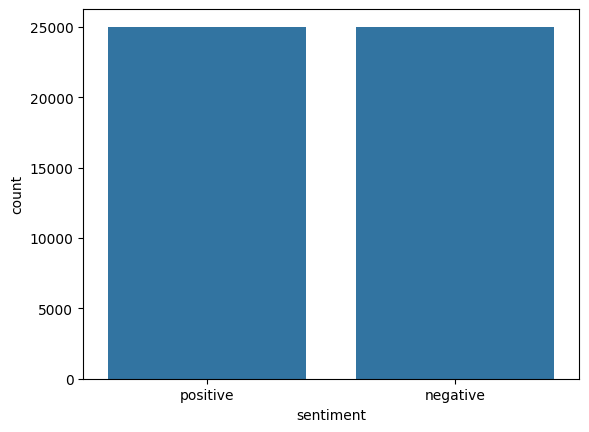

In [18]:
sns.countplot(x="sentiment", data=df)

plt.show()#same thing all together some code blocks

### Sentiment Distribution : dataset is distributed equally between positive and negative reviews

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


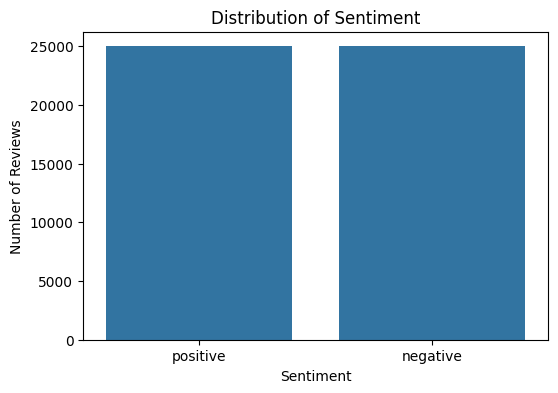

In [19]:
sentiment_counts = df['sentiment'].value_counts()#how many +ve and -ve values of sentiments are there in the dataset
print(sentiment_counts)#prints that values

import matplotlib.pyplot as plt#use these libraries to create and display a bar plot
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()#look if the data is actually balanced or not can infer from the graphs

# 2-Clean the data
 This involves preprocessing the text data, extracting features, training a classification model, and evaluating its performance.

### Subtask:
Cleaning and normalize the text data in the 'review' column and convert the target variable 'sentiment' into numerical format.


**Reasoning**:
The first step in text preprocessing is to convert the categorical 'sentiment' column into numerical format, which is required for machine learning models.



In [20]:
import re
import nltk

from nltk.corpus import stopwords

In [21]:
nltk.download('stopwords')
STOP_WORDS = set(stopwords.words("english"))

print(list(STOP_WORDS)[:20])
def clean_text(text):

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Keep only letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in STOP_WORDS
    ]

    return " ".join(words)


["aren't", 'but', 'ourselves', 'in', 'should', 'this', 'why', 'nor', 'on', 'them', 'they', "you'd", "wasn't", 'can', "hasn't", 'only', 'isn', "needn't", 't', 'themselves']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [22]:
sample = "This movie was AMAZING!!! <br /><br /> I loved it 100%."

print(clean_text(sample))

movie amazing loved


In [23]:
df["clean_review"] = df["review"].apply(clean_text)

In [24]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [25]:
print("ORIGINAL:\n")
print(df["review"].iloc[0])

print("\n" + "="*100 + "\n")

print("CLEANED:\n")
print(df["clean_review"].iloc[0])

ORIGINAL:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [26]:
print(df.columns)

Index(['review', 'sentiment', 'clean_review'], dtype='object')


In [27]:
print(df["review"].iloc[0][:300])
df["review"].head()
df["clean_review"].head()

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


,clean_review
0,one reviewers mentioned watching oz episode ho...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake thinks zombie...
4,petter mattei love time money visually stunnin...


In [29]:

df["clean_review"] = df["review"].apply(clean_text)
print("ORIGINAL:")
print(df["review"].iloc[0][:300])

print("\n")

print("CLEANED:")
print(df["clean_review"].iloc[0][:300])

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


CLEANED:
one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum secur


Importing tfidf

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer #
tfidf = TfidfVectorizer(
    max_features=5000
)

In [31]:
X = tfidf.fit_transform(df["clean_review"]) #convert text to numbers

In [32]:
print(X.shape)

(50000, 5000)


In [33]:
tfidf.get_feature_names_out()[:20]

array(['aaron', 'abandoned', 'abc', 'abilities', 'ability', 'able',
       'absence', 'absent', 'absolute', 'absolutely', 'absurd', 'abuse',
       'abused', 'abusive', 'abysmal', 'academy', 'accent', 'accents',
       'accept', 'acceptable'], dtype=object)

In [34]:
print(X[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 102 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 3103)	0.021827238444865726
  (0, 3691)	0.0792476797089306
  (0, 2794)	0.06832641147615395
  (0, 4840)	0.08045539400213889
  (0, 3147)	0.5556921710706617
  (0, 1479)	0.11933444573506098
  (0, 2135)	0.08669934179048938
  (0, 3707)	0.0894879323486094
  (0, 1525)	0.06024047775894111
  (0, 2014)	0.05998866624770228
  (0, 1718)	0.06634008473698393
  (0, 4466)	0.04040122572776445
  (0, 4256)	0.17339868358097876
  (0, 3834)	0.039719696189894196
  (0, 4770)	0.2443587914664922
  (0, 3918)	0.048661752398537206
  (0, 4945)	0.12242597645164832
  (0, 1907)	0.039274021285790245
  (0, 4616)	0.07608629252580455
  (0, 3973)	0.12603003499459514
  (0, 2053)	0.08080483699943034
  (0, 3461)	0.08259604546759877
  (0, 1345)	0.07623087690976454
  (0, 3928)	0.05613456581554082
  (0, 2021)	0.09024243564749951
  :	:
  (0, 1925)	0.04384540943860101
  (0, 2564)	0.07967513492352239
  (0, 1940)